<a href="https://colab.research.google.com/github/GustavoBLuz/Projetos_Aula/blob/Exercicios_Aula/Cliente2_Concessionaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cliente 1 — Concessionária de Veículos

**Análise CRISP-DM — Regressão Linear (Idade do carro x Preço)**

Este notebook segue todas as fases do processo CRISP-DM e está pronto para rodar no Google Colab / Jupyter.

## 1) Definição do Problema de Negócio

**Pergunta:** Consigo precificar o veículo baseado na sua idade?

**Objetivo:** Criar um modelo simples de regressão linear para precificação de veículos usados baseado na idade do automóvel.

**Escopo:** Regressão linear simples (1 variável preditora: Idade do veículo).

## 2) Pré-Processamento dos Dados

Importação de bibliotecas, configurações e tratamentos iniciais.

In [ ]:

# Imports e configurações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style('whitegrid')
print('Bibliotecas importadas com sucesso.')


Bibliotecas importadas com sucesso.


## 3) Extração e Carregamento

- Carregue seus dados aqui. Se não tiver um arquivo, o bloco abaixo gera um dataset simulado de exemplo. Substitua `df` usando `pd.read_csv('seu_arquivo.csv')` se preferir.

- Identificamos automaticamente as colunas numéricas e selecionamos as prováveis colunas de entrada (idade_anos) e alvo (preço_reais), devido a acharmos "furos" dentro das planilhas ao checar manualmente, foi feito uma varredura para limpar os dados e remover qualquer linha que tenha um valor NaN dentro dela, evitando contaminar as predições.

In [ ]:
# carregar CSV (descomente e ajuste o caminho se tiver o arquivo)
PATH = "dataset_2_regressao_limpo.csv"

df = pd.read_csv(PATH)

#
if 'quilometragem' in df.columns:
    mean_quilometragem = df['quilometragem'].mean()
    df['quilometragem'].fillna(mean_quilometragem, inplace=True)


display(df.head(100))
print("\nInformação do dataframe:")
display(df.info())
print("\nDescrição estatística:")
display(df.describe().T)

# heurística simples para detectar colunas X e y
def pick_columns_car(df):
    candidates = {c.lower(): c for c in df.columns}
    x_col = None
    y_col = None
    if 'idade_anos' in candidates:
        x_col = candidates['idade_anos']
    if 'preco_reais' in candidates:
        y_col = candidates['preco_reais']
    return x_col, y_col

x_col, y_col = pick_columns_car(df)
print('Colunas detectadas:', x_col, '->', y_col)

# remover NaNs nas colunas selecionadas
df_model = df[[x_col, y_col]].dropna().copy()
print('\nObservações após remoção de NaN:', len(df_model))

,idade_anos,preco_reais,quilometragem,marca,tipo_combustivel
0,4.782652,46630.805624,63767.639651,Ford,Gasolina
1,3.753586,65000.000000,53130.367272,Ford,Etanol
2,7.366469,65000.000000,110523.247364,Ford,Flex
3,4.097396,62256.112430,53130.367272,Volkswagen,Gasolina
4,5.558110,NaN,81121.321111,Honda,Gasolina
5,2.452702,50388.935746,39904.782941,Volkswagen,Etanol
6,4.800733,58745.604284,66672.899566,Honda,Gasolina
7,3.123008,NaN,46133.228528,Ford,Etanol
8,2.331458,54675.839946,35573.352425,Ford,Gasolina
9,3.323902,65000.000000,52430.726575,Volkswagen,Etanol



Informação do dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade_anos        49 non-null     float64
 1   preco_reais       48 non-null     float64
 2   quilometragem     50 non-null     float64
 3   marca             49 non-null     object 
 4   tipo_combustivel  50 non-null     object 
dtypes: float64(3), object(2)
memory usage: 2.1+ KB


None


Descrição estatística:


,count,mean,std,min,25%,50%,75%,max
idade_anos,49.0,3.614372,1.937415,1.030699,2.320133,3.123008,4.743350,10.723802
preco_reais,48.0,52451.807625,12527.539369,8920.755112,45220.866813,54287.499955,65000.000000,65000.000000
quilometragem,50.0,53130.367272,30005.726347,12055.430564,30276.106144,47571.344644,67224.082771,153186.459449


Colunas detectadas: idade_anos -> preco_reais

Observações após remoção de NaN: 47


## 4) Análise Exploratória (Exploratory Data Analysis/EDA)
Gráfico de dispersão: verificar se veículos mais antigos tendem a valer menos.

Correlação de Pearson: medir a relação entre idade e preço.

Estatísticas descritivas: idade média, preço médio, valores mínimos e máximos.

In [ ]:

# Informações gerais
print('Dimensões do dataset:', df.shape)
print('\nTipos de dados:')
display(df_model.dtypes)
print('\nResumo estatístico:')
display(df_model.describe().T)


Dimensões do dataset: (50, 5)

Tipos de dados:


,0
idade_anos,float64
preco_reais,float64



Resumo estatístico:


,count,mean,std,min,25%,50%,75%,max
idade_anos,47.0,3.583470,1.956635,1.030699,2.238037,3.078729,4.728398,10.723802
preco_reais,47.0,52302.283395,12619.606807,8920.755112,45148.243560,53899.159963,65000.000000,65000.000000


### Visualização
- Histogramas
- Gráfico de dispersão (idade_anos x preco_reais)
- Matriz de correlação

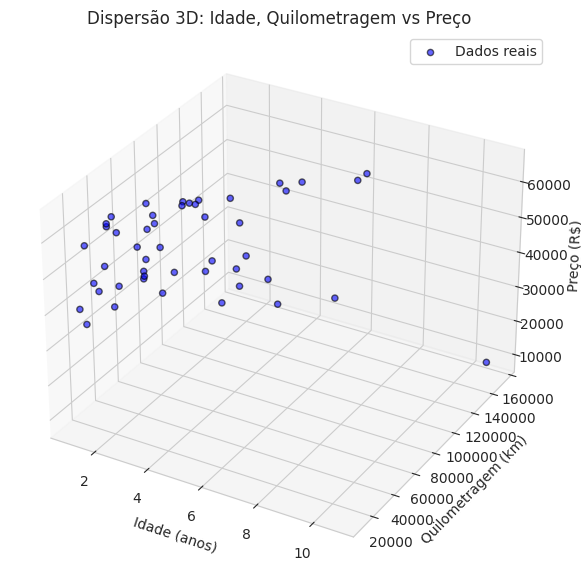

In [ ]:
# Grtáfico 3D (porquê são três variaveis)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Pontos reais usando o dataframe original depois de remover os NaN
df_plot = df.dropna(subset=['idade_anos', 'preco_reais', 'quilometragem']).copy()

ax.scatter(df_plot['idade_anos'], df_plot['quilometragem'], df_plot['preco_reais'],
           color='blue', alpha=0.6, edgecolor='k', label='Dados reais')

# Labels
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Quilometragem (km)')
ax.set_zlabel('Preço (R$)')
ax.set_title('Dispersão 3D: Idade, Quilometragem vs Preço')

plt.legend()
plt.show()

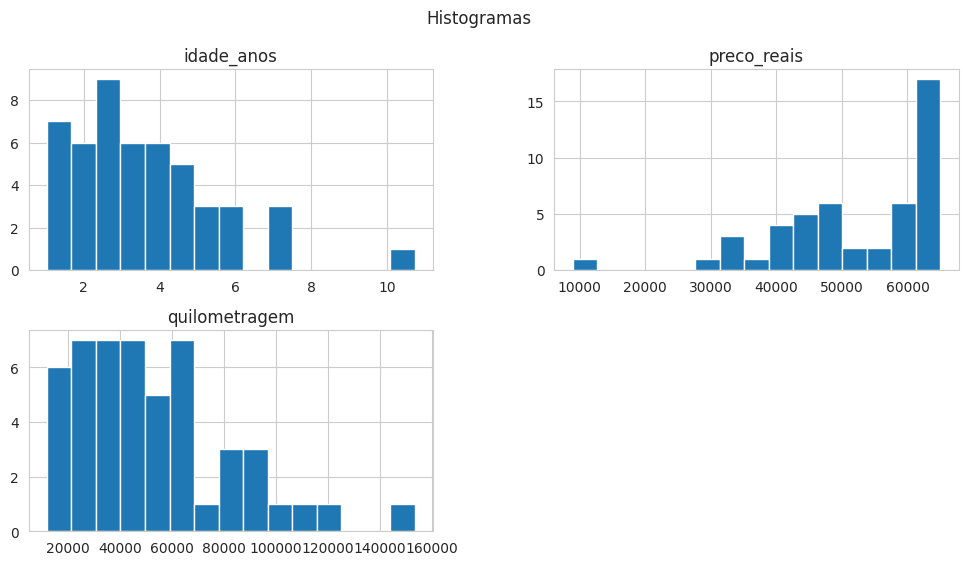

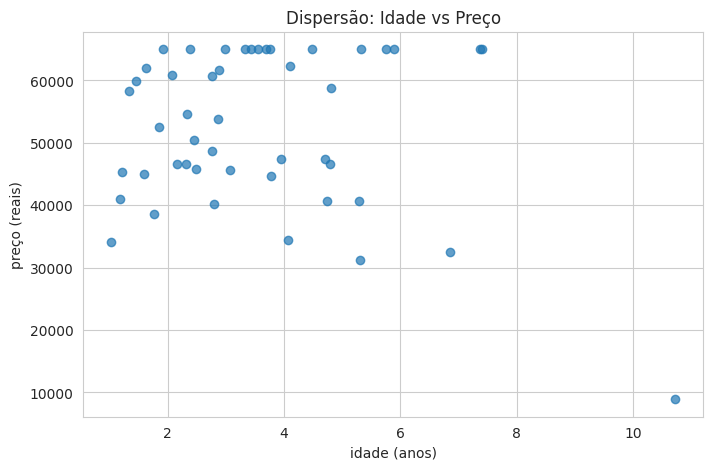

Matriz de correlação:


,idade_anos,preco_reais,quilometragem
idade_anos,1.000000,-0.196472,0.982899
preco_reais,-0.196472,1.000000,-0.204776
quilometragem,0.982899,-0.204776,1.000000


In [ ]:
# Histograma das variáveis
df.hist(bins=15, figsize=(12,6))
plt.suptitle('Histogramas')
plt.show()

plt.show()
# Scatter plot
plt.scatter(df_model[x_col], df_model[y_col], alpha=0.7)
plt.xlabel('idade (anos)')
plt.ylabel('preço (reais)')
plt.title('Dispersão: Idade vs Preço')
plt.show()

# Correlação
numeric_df = df.select_dtypes(include=[np.number]) # Seleciona apenas colunas númericas
corr = numeric_df.corr()
print('Matriz de correlação:')
display(corr)

## 5) Aprendizado dos Algoritmos

Usaremos Regressão Linear Simples para modelar a relação:  

$y = \beta_0 + \beta_1 x + \epsilon$  

Onde:
- $x$ = Idade em anos
- $y$ = Preço

### 6) Regressão Linear com Scikit-learn
#### Baseado na quantidade limitada de 47 dados, iremos separar em 80% de Treino e 20% para Teste (80% treino / 20% teste), esperamos ter uma precisão mais exata e confiavel através dessa.

#### Criando o modelo de regressão e treinando

In [ ]:
# Preparar X e y
X = df_model[[x_col]].values
y = df_model[y_col].values

# Separar em treino e teste (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f'Tamanho treino: {len(X_train)}, tamanho teste: {len(X_test)}')

Tamanho treino: 37, tamanho teste: 10


In [ ]:

# Criando o modelo
modelo = LinearRegression()

# Treinando o modelo
modelo.fit(X_train, y_train)

# Coeficientes
b1 = modelo.coef_[0]
b0 = modelo.intercept_
print(f'Intercepto (b0): {b0:.4f}')
print(f'Coeficiente angular (b1): {b1:.4f}')


Intercepto (b0): 59870.2975
Coeficiente angular (b1): -1883.3579


## 7) Validação, Avaliação e Otimização

Calcular previsões e métricas de avaliação.

In [ ]:

# Previsões no conjunto de teste
y_pred = modelo.predict(X_test)

# Métricas
mse = mean_squared_error(y_test, y_pred)      #MSE, Média dos erros ao quadrado
rmse = np.sqrt(mse)                           # RMSE raiz do MSE
mae = mean_absolute_error(y_test, y_pred)     #MAE, Média das diferenças absolutas
r2 = r2_score(y_test, y_pred)                 #Calcula o R² dentro do teste, para qualidade de novos dados
score_method = modelo.score(X_test, y_test)   # .score() retorna R² para regressão

#Mostra os dados calculados, R² de treino, teste, o ajuste feito, o MAE e o RMSE e o Score
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² (r2_score): {r2:.4f}')
print(f'.score() do modelo: {score_method:.4f}  (equivalente ao R²)')


MSE: 115429304.4518
RMSE: 10743.8031
MAE: 9188.9968
R² (r2_score): -0.4803
.score() do modelo: -0.4803  (equivalente ao R²)


### Análise dos Resíduos e Visualizações de Avaliação

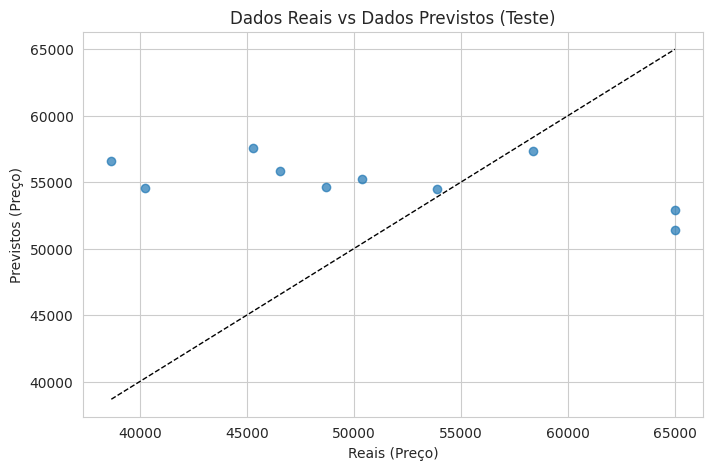

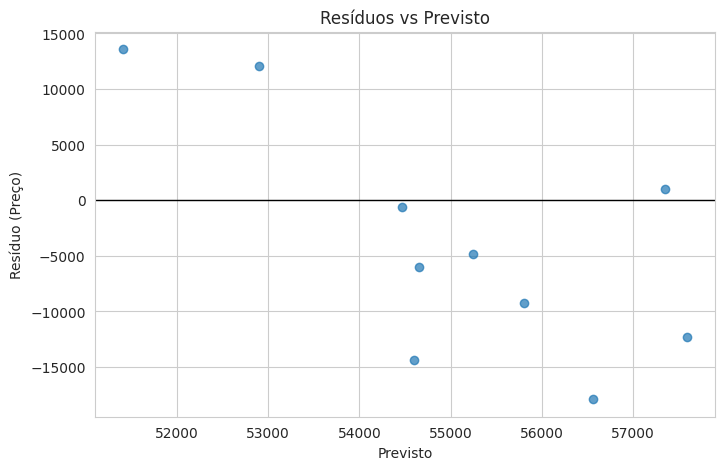

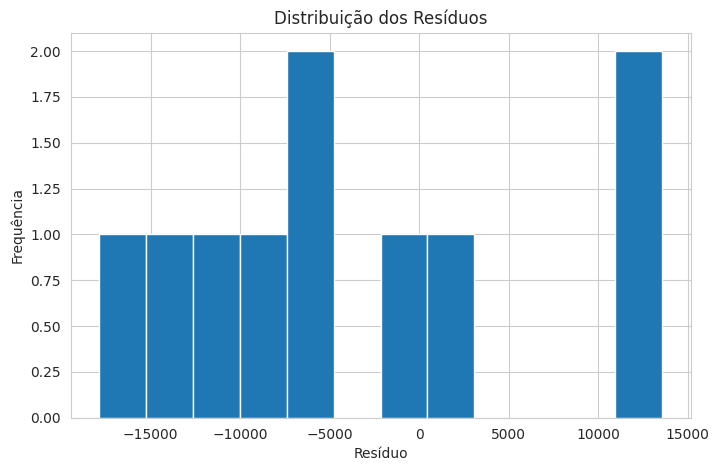

In [ ]:
# Gráfico: pontos de teste (real vs previsto)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Reais (Preço)')
plt.ylabel('Previstos (Preço)')
plt.title('Dados Reais vs Dados Previstos (Teste)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
plt.show()

# Residuals
residuos = y_test - y_pred
plt.scatter(y_pred, residuos, alpha=0.7)
plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Previsto')                    #nome do eixo x (com a mesma label do arquivo)
plt.ylabel('Resíduo (Preço)')            #nome do eixo y (com a mesma label do arquivo)
plt.title('Resíduos vs Previsto')
plt.show()                                #printa o grafico

# Histograma dos resíduos
plt.hist(residuos, bins=12)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduo')
plt.ylabel('Frequência')
plt.show()

### O que faz a função `.score()`?

No caso de regressão, `.score(X, y)` retorna o **coeficiente de determinação R²**, que mede a proporção da variância em y explicada por X. Valores próximos de 1 indicam bom ajuste; valores próximos de 0 indicam ajuste ruim.

## 8) Previsão / Predição

Exemplos de predição com novos valores de temperatura.

In [ ]:
# Predição para novas idades
novas_idades = np.array([[1.0], [5.0], [10.0]]) # Exemplo de idades (em anos)
previsoes = modelo.predict(novas_idades)
for idade, preco_previsto in zip(novas_idades.flatten(), previsoes):
    print(f'Idade {idade:.1f} anos -> Preço previsto: R$ {preco_previsto:.2f}')

Idade 1.0 anos -> Preço previsto: R$ 57986.94
Idade 5.0 anos -> Preço previsto: R$ 50453.51
Idade 10.0 anos -> Preço previsto: R$ 41036.72


## 9) Salvando o resultado do seu trabalho

- Salvar o modelo treinado e registrar métricas em arquivo para reprodução/implantação, para assim poder enviar ao cliente os resultados encontrados junto dos comentários.

In [ ]:
# Salvar um relatório simples em Markdown
relatorio = f"""# Relatório — Precificação de Veículos Usados

Equação do modelo:
Preço = {b0:.3f} + {b1:.3f} * Idade

Métricas (teste):
- MSE: {mse:.3f}
- RMSE: {rmse:.3f}
- MAE: {mae:.3f}
- R2: {r2:.3f}

"""

with open('Relatorio_Sorveteria.md', 'w', encoding='utf-8') as f:
    f.write(relatorio) #salva o relatorio dentro de um .md (também pra fazer download dentro do colab)

print('Relatório salvo: Relatorio_Sorveteria.md')

Relatório salvo: Relatorio_Sorveteria.md


## 10) Resumo das Métricas Utilizadas

- **MSE (Mean Squared Error):** média dos quadrados dos erros. Quanto menor, melhor.
- **RMSE:** raiz do MSE — traz a métrica para a unidade original (aqui: unidades de vendas).
- **MAE (Mean Absolute Error):** média dos erros absolutos — interpretação direta em unidades.
- **R² (Coeficiente de Determinação):** proporção da variância explicada pelo modelo.

---

## 11) Resumo Final e Recomendações

Com base no modelo:
- Interprete o coeficiente e intervalo de confiança (abaixo) para validar significância.
- Use o modelo para planejamento de estoque em dias de previsão de calor.
- Considere adicionar variáveis (promoções, dia da semana, temperatura percebida) para melhorar o modelo.

### Intervalo de Confiança (IC 95%) para os coeficientes

In [ ]:

# Usando statsmodels para IC do coeficiente
X_sm = sm.add_constant(X)  # para todo o conjunto (melhor estimativa dos coeficientes)
est = sm.OLS(y, X_sm).fit()
print(est.summary())
print('\nIntervalo de confiança (95%) para coeficientes:')
print(est.conf_int(alpha=0.05))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     1.807
Date:                Mon, 08 Sep 2025   Prob (F-statistic):              0.186
Time:                        23:22:49   Log-Likelihood:                -509.08
No. Observations:                  47   AIC:                             1022.
Df Residuals:                      45   BIC:                             1026.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.684e+04   3839.560     14.805      0.0

## 12) Sugestões baseado nos dados
- O coeficiente encontrado na temperatura é positivo, o que indica que as vendas sim aumentam com base na temperatura, sendo 66.5% da variação dentro dos dados informados.
- O coeficiente de temperatura retornou 123.1390, ou seja, para cada 1°C que aumenta, o experado aumento valor das vendas está dentro desta média, não é todo caso, mas sim a têndencia em aumentar.

In [ ]:
# Salvar um relatório simples em Markdown
relatorio = f"""# Relatório — Precificação de Veículos Usados

Equação do modelo:
Preço = {b0:.3f} (Mudança estimada) + {b1:.3f} (Desvalorização) * Idade

Métricas (teste):
- MSE: {mse:.3f}
- RMSE: {rmse:.3f}
- MAE: {mae:.3f}
- R2: {r2:.3f}

"""

with open('Relatorio_Veiculos.md', 'w', encoding='utf-8') as f:
    f.write(relatorio) #salva o relatorio dentro de um .md (também pra fazer download dentro do colab)

print('Relatório salvo: Relatorio_Veiculos.md')

Relatório salvo: Relatorio_Veiculos.md
